In [1]:
import pandas as pd
import numpy as np
import re
import os
import glob
import json
import seaborn as sns
import matplotlib.pyplot as plt

## Smoothing text
This fixes inchoerent paragraph and sentence splits to obtain the best input for our inscription extraction scheme.

The function `clean_armenian_text` is designed to process raw Armenian text extracted from documents (such as OCR outputs or scanned books) and convert it into a more structured and readable format. Its main cleaning steps are:

1. **Page Splitting**
   - The text is split into pages using regex, preserving explicit page markers of the form:
     ```
     --- Page N ---
     ```
   - These page markers are kept as standalone paragraphs for reference.

2. **Page Content Cleaning**
   Each page undergoes several normalization steps:
   - **Hyphenated Line Breaks:**  
     Removes artificial word breaks across lines by joining words split with `-` followed by a newline.
   - **Paragraph Breaks for Special Markers:**  
     Ensures that lines starting with Armenian annotations (e.g., `Հրատ.` or `Ծանոթ.`) begin on a new paragraph.
   - **Line Splitting:**  
     Each page is processed line by line to handle different formatting cases.

3. **Block Detection**
   Two types of text blocks are identified:
   - **ALL CAPS Blocks:**  
     Lines consisting only of uppercase Armenian letters, digits, and limited punctuation are treated as headings or emphasized sections. Consecutive matching lines are grouped together.
   - **Normal Paragraphs:**  
     Other text is merged into paragraphs by joining consecutive non-empty lines until a blank line is encountered. Single line breaks inside paragraphs are flattened into spaces for smoother reading.

4. **Reconstruction**
   - Within each page, blocks are separated by **double newlines**.
   - At the end, all cleaned pages are reassembled into the final cleaned document with preserved page structure.

---

## File Cleaning Workflow

The helper function `clean_file(input_path, output_path)` automates the process:
1. Reads the original text file.
2. Cleans the content using `clean_armenian_text`.
3. Writes the cleaned version into a new file at the specified output path.
4. Prints a confirmation message with the saved location.

---

### Example Usage
```python
clean_file(
    "C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/Divan_Prak10.txt",
    "divan_prak10_cleaned.txt"
)


In [2]:
import re
def clean_armenian_text(text: str) -> str:
    # 1) Split text into pages (keep page numbers)
    pages = re.split(r"(---\s*Page\s+\d+\s*---)", text, flags=re.IGNORECASE)

    cleaned_pages = []

    for page in pages:
        page = page.strip()
        if not page:
            continue

        # If this is a page marker, keep as its own paragraph
        if re.match(r"---\s*Page\s+\d+\s*---", page, flags=re.IGNORECASE):
            cleaned_pages.append(page)
            continue

        # Otherwise, clean the page content
        
        # Fix hyphenated line breaks
        page = re.sub(r'-\n\s*', '', page)

        # Force paragraph breaks before lines starting with special markers
        page = re.sub(r'\n(?=(Հրատ\.|Ծանոթ\.))', r'\n\n', page)

        # Split lines to detect ALL CAPS blocks
        lines = page.splitlines()
        cleaned_lines = []
        valid_pattern = re.compile(r"^[Ա-Ֆ0-9\s\.\-,:;#\[\]\(\)]+$")

        i = 0
        while i < len(lines):
            line = lines[i].strip()
            if not line:
                cleaned_lines.append("")
                i += 1
                continue

            # Check if this line starts an ALL CAPS block
            if valid_pattern.match(line):
                block = [line]
                i += 1
                while i < len(lines) and valid_pattern.match(lines[i].strip()):
                    block.append(lines[i].strip())
                    i += 1
                cleaned_lines.append("\n".join(block))
            else:
                # Normal text: merge lines until next blank line
                normal_para = [line]
                i += 1
                while i < len(lines) and lines[i].strip() and not valid_pattern.match(lines[i].strip()):
                    normal_para.append(lines[i].strip())
                    i += 1
                # Flatten single newlines into spaces
                para_text = " ".join(normal_para)
                para_text = re.sub(r'\s{2,}', ' ', para_text)
                cleaned_lines.append(para_text)

        cleaned_pages.append("\n\n".join(cleaned_lines))

    # Reassemble all pages with double newlines
    return "\n\n".join(cleaned_pages)




def clean_file(input_path: str, output_path: str):
    # Read original text
    with open(input_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Clean it
    cleaned_text = clean_armenian_text(text)

    # Write new cleaned file
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(cleaned_text)

    print(f"Cleaned file saved as: {output_path}")


# Example usage:


# Inscription Extraction

# Armenian Inscription Extraction

## Extraction around Predefined Structure

This extraction scheme assumes that **all inscriptions** in the corpus follow a semi-standardized structure, consisting of:

1. **Title Line (Description with Line Count)**  
   - Format:  
     ```
     Inscription Number. LOCATION OF ARTEFACT (ALL CAPS + "."). Description ... Number of Lines + one of ["տող.", "միատող.", "տողից."]
     ```

2. **Inscription Text Block**  
   - One or more consecutive lines in **ALL CAPS with limited punctuation** (Armenian letters, digits, brackets, punctuation).

3. **Publication Line**  
   - Starts with `Հրատ.` followed by publication details.

4. **Note Line**  
   - Starts with `Ծանոթ.` followed by commentary or annotations.

---

## Extraction Workflow

The function `extract_inscriptions_hybrid` performs a **two-pass hybrid extraction** to capture inscriptions robustly.

### Pass 1: Deterministic Extraction
- **Page Splitting:**  
  Input text is split into **pages** using page markers (`--- Page N ---`).  
- **Relevant Page Detection:**  
  Only pages that contain one of the keywords `տող.`, `միատող.`, `Հրատ.`, `Ծանոթ.` are processed.  
- **Within Each Page:**  
  - **Title Detection:**  
    Uses `is_valid_title()` to detect inscription titles with the expected regex (number + dot + ALL CAPS + dot).  
  - **Inscription Collection:**  
    Collects consecutive **ALL CAPS lines** until a `Հրատ.` or `Ծանոթ.` marker.  
  - **Publication & Note Extraction:**  
    Attaches publication and note details if present.  
- **Structured Entry:**  
  Each detected inscription is stored as:
  ```json
  {
    "page": <page_number>,
    "title": "...",
    "inscription": "...",
    "publication": "...",
    "note": "..."
  }

### Pass 2: Fallback Term-Driven Extraction

- Handles inscriptions that may be **broken across lines or pages**.

- Uses `generate_term_ranking()` to locate terms of interest:

    - Description markers: տող., միատող., տողից.
    
    - Publication marker: Հրատ.
    
    - Note marker: Ծանոթ.

- **Special Cases:**

    - Description → Note sequences: Detects when a description is immediately followed by a note.

    - Description → Description sequences: Handles consecutive inscriptions on the same page.

    - Cross-page detection: If an inscription starts on one page and continues with publication/note on the next, it merges them.

### Supporting Utilities

Several helper functions support robust extraction:

- `transform_words(strings)`
Expands a list of terms into multiple forms: original, uppercase, lowercase, stripped of punctuation.
Ensures flexible matching against OCR noise or casing inconsistencies.

- `extract_all_caps_block(text)`
Groups together consecutive ALL CAPS lines into candidate inscription texts.

- `find_line(text, last_index, term)`
Retrieves the full line in which a keyword (e.g., տող.) appears.

- `is_valid_title(line)`
Checks whether a line matches the expected title format (numbered inscription header).



flowchart TD


    A[Raw Text with Pages] --> B[Split into Pages]

    B --> C{Contains Keywords?}

    C -->|No| D[Skip Page]

    C -->|Yes| E[Pass 1: Deterministic Extraction]

    E --> F[Entries with Title, Inscription, Publication, Note]

    B --> G[Pass 2: Fallback Extraction]

    G --> H[Handle Cross-Page & Missed Cases]

    F --> I[Combine Results]

    H --> I[Combine Results]
    
    I --> J[Write JSONL Output]


- Output is structured JSONL, suitable for downstream NLP tasks, archival, or search.

- he workflow ensures robustness against OCR inconsistencies and variation in document formatting.

- **DOWNSIDE** this function might be *too* precise, where it won't extract inscriptions that have remotely different structures

In [3]:
import re
import string

def transform_words(strings):
    """
    Takes a list of strings and returns a flat list of words in different forms:
    original (with punctuation), upper, lower, stripped.
    """
    results = []

    for s in strings:
        words = s.split()

        for w in words:
            stripped = w.strip(string.punctuation)
            results.extend([w, w.upper(), w.lower(), stripped])

    return results


# Example usage
strings = ["Ծանոթ.", "տող.","միատող.","տողից."]
output = transform_words(strings)
output



['Ծանոթ.',
 'ԾԱՆՈԹ.',
 'ծանոթ.',
 'Ծանոթ',
 'տող.',
 'ՏՈՂ.',
 'տող.',
 'տող',
 'միատող.',
 'ՄԻԱՏՈՂ.',
 'միատող.',
 'միատող',
 'տողից.',
 'ՏՈՂԻՑ.',
 'տողից.',
 'տողից']

In [4]:

import re
import json

def is_valid_title(line: str) -> bool:
    """
    Checks if a line is a valid inscription title.
    Format: number + dot, ALL CAPS TEXT (with punctuation allowed).
    """
    line = line.strip()
    pattern = r"^\d+\.\s+[Ա-ՖԵՕՒՔ\s\.\-,:;()\[\]#]+?\."
    return bool(re.match(pattern, line))

def find_line(text, last_index, term):
    start_index = text.rfind("\n", 0, last_index)
    if start_index == -1:
        start_index = 0
    else:
        start_index += 1
    return text[start_index:last_index + len(term)]

def extract_all_caps_block(text):
    lines = text.splitlines()
    all_caps_blocks, current_block = [], []
    valid_pattern = re.compile(r"^[Ա-Ֆ0-9\s\.\-,:;#\[\]\(\)]+$")

    for line in lines:
        stripped = line.strip()
        if not stripped:
            if current_block:
                all_caps_blocks.append("\n".join(current_block))
                current_block = []
            continue
        if valid_pattern.match(stripped):
            current_block.append(stripped)
        else:
            if current_block:
                all_caps_blocks.append("\n".join(current_block))
                current_block = []
    if current_block:
        all_caps_blocks.append("\n".join(current_block))
    return all_caps_blocks

def generate_term_ranking(text, terms_of_interest=["Ծանոթ.", "տող.","միատող.","տողից."]):
    lists = []
    terms_of_interest=transform_words(terms_of_interest)
    for term in terms_of_interest:
        matches = [m.start() for m in re.finditer(term, text, re.IGNORECASE)]
        current_list = []
        if term in transform_words(["միատող.","տող.","տողից."]): 
            for index in matches:
                line = find_line(text,index,term)
                if is_valid_title(line):
                    current_list.append((term,index))
        else:
            current_list = [(term,m) for m in matches]
        lists.append(current_list)

    flattened = [item for sublist in lists for item in sublist]
    return sorted(flattened, key=lambda x: x[1])

def extract_inscriptions_hybrid(txt_file, output_jsonl):
    results = []

    with open(txt_file, "r", encoding="utf-8") as f:
        text = f.read()

    # Split into pages
    pages = re.split(r"---\s*Page\s+(\d+)\s*---", text, flags=re.IGNORECASE)
    corpus = {}
    for i in range(1, len(pages), 2):
        page_num = int(pages[i])
        page_text = pages[i+1]
        if any(keyword in page_text for keyword in transform_words(["Ծանոթ.", "տող.","Հրատ.","միատող."])):
            corpus[page_num] = page_text

    items = list(corpus.items())

    # Pass 1: deterministic
    for page_num, page_text in items:
        lines = [line.strip() for line in page_text.splitlines() if line.strip()]
        j = 0
        while j < len(lines):
            line = lines[j]
            desc_match = re.match(r"^(\d+\..*?(?:տող\.|միատող\.))", line)
            if desc_match:
                entry = {
                    "page": page_num,
                    "title": desc_match.group(1).strip(),
                    "inscription": "",
                    "publication": None,
                    "note": None
                }
                k = j+1
                inscription_lines = []
                while k < len(lines):
                    nxt = lines[k]
                    if nxt.startswith("Հրատ."):
                        entry["publication"] = nxt
                        k += 1
                        break
                    elif nxt.startswith("Ծանոթ.") or re.match(r"^\d+\.", nxt):
                        break
                    elif not re.search(r"[ա-ֆ]", nxt):
                        inscription_lines.append(nxt)
                    k += 1
                entry["inscription"] = " ".join(inscription_lines).strip()

                while k < len(lines):
                    nxt = lines[k]
                    if nxt.startswith("Ծանոթ."):
                        note_lines = [nxt]
                        m = k+1
                        while m < len(lines):
                            nxt2 = lines[m]
                            if nxt2.startswith("Հրատ.") or nxt2.startswith("Ծանոթ.") or re.match(r"^\d+\.", nxt2):
                                break
                            note_lines.append(nxt2)
                            m += 1
                        entry["note"] = " ".join(note_lines).strip()
                        k = m
                        break
                    else:
                        k += 1

                results.append(entry)
                j = k
            else:
                j += 1

    # Pass 2: fallback term-driven (to catch missed / cross-page)
    for (key1, text1), (key2, text2) in zip(items, items[1:]):
        terms1 = generate_term_ranking(text1)
        for (term1, idx1), (term2, idx2) in zip(terms1, terms1[1:]):
            if term1 in transform_words(["միատող.","տող.","տողից."]) and term2 in transform_words(["Ծանոթ."]):  # case desc → note
                inscribtion_text = text1[idx1+len(term1):idx2-1]
                publication_detection= generate_term_ranking(inscribtion_text,transform_words(["Հրատ."]))
                if len(publication_detection)>0:
                    split = inscribtion_text.split(publication_detection[0][0])
                    publication = None
                    if len(split) > 1:
                        publication = publication_detection[0][0] + split[-1]
                        inscribtion_text = split[0]

                note = text1[idx2:].split('\n\n')[0]
                title = find_line(text1, idx1, term1)
                results.append({
                    'page': key1,
                    'title': title.split('.')[0]+'.'+title.split('.')[1],
                    'inscription': inscribtion_text,
                    'publication': publication,
                    'note': note
                })

            if term1 in transform_words(["միատող.","տող.","տողից."]) and term2 in transform_words(["միատող.","տող.","տողից."]):##Case 2 desc desc
                if term1 in transform_words(['միատող.']) and term2 in transform_words(['տող.']) and idx1-3==idx2:
                    continue
                elif term2 in transform_words(['միատող.']) and term1 in transform_words(['տող.']) and idx1+3==idx2:
                    continue
                else:
                    title=find_line(text1,idx1,term1)
                    inscribtion_text=text1[idx1+len(term1):idx2-1]
                    publication = None
                    publication_detection= generate_term_ranking(inscribtion_text,transform_words(["Հրատ."]))
                    if len(publication_detection)>0:
                        split = inscribtion_text.split(publication_detection[0][0])
                        if len(split) > 1:
                            publication = publication_detection[0][0] + split[-1]
                            inscribtion_text = split[0]

                    current_entry={'page': key1,
                               'title':title.split('.')[0]+'.'+title.split('.')[1],
                                'inscribtion':" ".join(s for sub in inscribtion_text for s in sub),
                                'publication':publication,
                                'note':None}
                    results.append(current_entry)
                    
        # handle cross-page desc → note
        if key1+1 == key2:
            terms2 = generate_term_ranking(text2)
            if terms1 and terms2:
                if terms1[-1][0] in transform_words(["միատող.","տող.","տողից."]) in transform_words(["Ծանոթ."]): 
                    new_text = find_line(text1,terms1[-1][1],terms1[-1][0]) + text2
                    new_terms = generate_term_ranking(new_text)
                    idx1, idx2 = new_terms[0][1], new_terms[1][1]
                    term1, term2 = new_terms[0][0], new_terms[1][0]
                    inscribtion_text = text1[idx1+len(term1):idx2-1]

                    publication_detection= generate_term_ranking(inscribtion_text,transform_words(["Հրատ."]))
                    if len(publication_detection)>0:
                        split = inscribtion_text.split(publication_detection[0][0])
                        publication = None
                        if len(split) > 1:
                            publication = publication_detection[0][0] + split[-1]
                            inscribtion_text = split[0]
                            
                    title=find_line(new_text,idx1,term1)
                    results.append({
                        'page': key1,
                        'title':title.split('.')[0]+'.'+title.split('.')[1],
                        'inscription':inscribtion_text,
                        'publication':publication,
                        'note':note
                    })

    # Write JSONL
    with open(output_jsonl, "w", encoding="utf-8") as out:
        for entry in results:
            out.write(json.dumps(entry, ensure_ascii=False) + "\n")

## Pipeline for cleaning and extraction


In [6]:
def clean_and_extract_inscriptions(original_text, target_jsonl):
    target_cleaned=original_text.split('.txt')[0]+"_clean.txt"
    clean_file(original_text,target_cleaned)
    extract_inscriptions_hybrid(target_cleaned,target_jsonl)

    df=pd.read_json(target_jsonl,lines=True)
    if len(df)==0:
        return df
    df['inscribtion_number']=df['title'].apply(lambda x : int(str(x).split('.')[0]))

    df['_nan_count'] = df.drop(columns=['page', 'inscribtion_number']).isna().sum(axis=1)

    idx = df.groupby(['page', 'inscribtion_number'])['_nan_count'].idxmin()

    df_cleaned = df.loc[idx].drop(columns=['_nan_count']).reset_index(drop=True)

    df_cleaned = df_cleaned.sort_values(by='inscribtion_number').reset_index(drop=True)

    df_cleaned.to_json(target_jsonl,orient='records',lines=True,force_ascii=False)
    return df_cleaned

#hybrid_df=clean_and_extract_inscriptions("C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/Divan_Prak10.txt", "divan_prak10_hybrid.jsonl")


In [9]:
base_dir="C:/Users/Kamal/OneDrive/Desktop/PDS/corpus_txt/"

## Analysis

In [8]:
df=pd.read_json('divan_prak10_hybrid.jsonl',lines=True)
df['Inscribtion_Number']=df['title'].apply(lambda x : int(str(x).split('.')[0]))
df['_nan_count'] = df.drop(columns=['page', 'Inscribtion_Number']).isna().sum(axis=1)

# For each group, keep the row with the minimum NaN count
idx = df.groupby(['page', 'Inscribtion_Number'])['_nan_count'].idxmin()


df_cleaned = df.loc[idx].drop(columns=['_nan_count']).reset_index(drop=True)

# Optional: sort by Inscribtion_Number
df_cleaned = df_cleaned.sort_values(by='Inscribtion_Number').reset_index(drop=True)
df_cleaned

,page,title,inscription,publication,note,inscribtion,inscribtion_number,Inscribtion_Number
0,19,2. Ա.ՆԵԱՆ եԿԵՂԵՑԻ. հյուսիսային դռան վերնամասու...,ԱՌԱՄԱԲԱՂԻ ԱՈԱՏԱԲԱԵԽ#Ր## ՊԱՅՑԱՌԱՕԱՅԼ ԱՅՔ ԱՅՓԱՌԱ...,"Հրատ. Գէորգեանց, 127։",Ծանոթ. Վիմագիրն ամփոփում էեկեղեցու շինարարությ...,None,2,2
1,21,"3. ԵՐԵՐՈՒՅԹԻ ՏԱԾԱՐ. բեմից հյուսիս, մույթի վրա,...",Ն ՀԱՎԱՏԱՑԵԼՈՑ Ի ՔՍՆՈՐՈՅՅԵՑԻ,None,Ծանոթ. Հրատարակել է միայն ակադ. ն. Սառը (ռուսե...,None,3,3
2,22,5. ԵՐԵՐՈՒՅՔԻ ՏԱԾԱՐ. հարավային պատի արևելյան մո...,Ե# ՅԱՆՈՒՆ ԱՅՀՁՈՐԻ ԵՒ ԱՆՍԱՀԻ].. ՏԱՅՈՅԹՎԿԻՍ ԻԷՒԱՆ,None,Ծանոթ. Գրիչը չի շարունակել։,None,5,5
3,22,"6. ԵՐԵՐՈՒՅՔԻ ՏԱԾԱՐ. հյուսիսային պատին, ներքուս...",ԺՆ ՌՈԲՉԽՍՅԱՂՈՒԹՍ,None,Ծանոթ. Վերջին նախադասությունն այլ գրչով է և ան...,None,6,6
4,23,"7. ԵՐԵՐՈՒՅՔԻ ՏԱՅԱՐ. հարավային պատին, քերծագրով...",ՏՐԳՐԻԳՈՐ ՀԱՅ]ՐԱՊԵՏ ԼՈՒՍԱՒՈՐԻՉ]։,"Հրատ. Աշ. Սանուչարյան, 30, X#. 291։",Ծանոթ. Սեզ առաջին անգամ է հանդիպում Լուսավորչի...,None,7,7
...,...,...,...,...,...,...,...,...
134,121,"188. ՏԱՊԱՆԱԹԱՐ. օրորոցածև, հյուսիսային և հարավ...",ԽԱՈՍ ԱԱՒՆՆԵՄԵ ԱԳԱՐԱԲԱՂԴ ԳԹՈԺԱՍԱԱՅԻՆԶ ՄԱՀՈԿ ԱՆՅ...,None,None,None,188,188
135,122,"190. ՏԱՊԱՆԱՔԱՐ. օրորոցածև, հարավային նիստին, 4...","ԱՅՍ Է ՏԱՊԱՆՆ ՅՕՀԱՆԷՍԻ] ԱԲԿԱՐԵԱՆՑ, ՈՐ ԷՐ ԴԸՊԻՐԵ...",None,None,None,190,190
136,51,"562. Ա.ԱՍՏՎԱՑԱՅԻՆ ԵԿԵՂԵՑԻ. արևելյան պատին, կտի...",ՄԱՅՐ ՔՍԻ /1858։ -47-,None,None,None,562,562
137,105,"1150. ՏԱՊԱՆԱԹԱՐ. ուղղանկյուն սալ, վանքի հյուսի...",ԶՍԱՐԳԻՍ ##ԱՀԱՆԱ ՅԻՇԵՍ]ԻՏՐ,"Հրատ. Ор#б###, ######## 448.","Ծանոթ. Այս տապանագիրը մեզ չհաջողվեց գտնել, ուս...",None,1150,1150


### Where does out method fail? Where do notes not exist?
- page 26: No Note
- page 27: No Note
- Page 28: Dzanot without period
- Page 29: No Note
- Page 31: No Note
- Page 37: No Note
- Page 44: No note
- Page 46: Ցանոթ.
- Page 47: No Note


In [10]:
len(df_cleaned[df_cleaned['note'].isna()])

49

## Title-Based Inscription Extraction Pipeline

This pipeline extracts inscriptions and their metadata from cleaned Armenian text files.  
It is built around the assumption that each inscription begins with a **numbered title line** and may include structured elements such as inscription text, publication references, and notes.

---

### Extraction Assumptions

1. **Title Line**  
   - Always begins with a number and a dot (`\d+\.`).  
   - Followed by **ALL CAPS Armenian text** (artefact location, description).  
   - Ends with a dot.  
   Example:  **12. ԱՐՏԵՖԱԿՏ ԳՅՈՒՂ.**

2. **Content Block**  
- Follows directly under the title.  
- May include normal Armenian sentences and/or ALL CAPS inscription text.  

3. **Inscription Block**  
- Extracted as consecutive **ALL CAPS lines** (using `extract_all_caps_block`).  

4. **Publication Line**  
- Marked by `Հրատ.` followed by publication details.  

5. **Note Line**  
- Marked by `Ծանոթ.` followed by commentary or annotations.  

---

### Pipeline Steps

1. **Page Splitting (`load_pages`)**  
- Splits the cleaned text into pages using markers of the form:  
  ```
  --- Page N ---
  ```  
- Returns a dictionary `{page_num: page_text}`.

2. **Title & Content Extraction (`extract_titles_and_content`)**  
- Uses regex pattern:  
  ```
  (\d+\.\s+(?:[Ա-ՖԵՕՒՔ\s\.]+?\.)+)
  ```  
- Captures numbered titles and assigns the following block of text as the content.  
- Produces a mapping `{page: [(title, content), ...]}`.

3. **Data Structuring (`build_dataframe`)**  
- Converts the extraction dictionary into a DataFrame with columns:  
  - `page`  
  - `title`  
  - `content`  

4. **Metadata Enrichment (`enrich_dataframe`)**  
- **Inscription Extraction:** Finds ALL CAPS blocks inside `content`.  
- **Publication Detection:** Extracts lines starting with `Հրատ.`.  
- **Note Detection:** Extracts lines starting with `Ծանոթ.`.  
- **Inscription Number:** Derived from the numeric prefix of `title`.  
- Removes duplicate inscription numbers (keeping the first occurrence).  

5. **Final Output (`run_title_based_pipeline`)**  
- Returns a DataFrame with the following structured fields:  
  - `page` – page number of the inscription  
  - `title` – inscription header (numbered title)  
  - `content` – raw text under the title  
  - `inscription` – extracted ALL CAPS block(s)  
  - `publication` – extracted publication reference (if any)  
  - `note` – extracted note (if any)  
  - `inscription_number` – integer identifier from the title  

---

## Example Output

```text
page   inscription_number   title                     inscription   publication   note
42     12                  12. ԱՐՏԵՖԱԿՏ ...         "ALL CAPS..."  "Հրատ. ..."   "Ծանոթ. ..."


In [7]:
def generate_term_ranking_unique(text, terms_of_interest=["Ծանոթ.", "տող.","միատող.","տողից."]):
    lists = []
    expanded_terms = transform_words(terms_of_interest)

    def normalize(term):
        # normalize variants back to their canonical form
        if term in transform_words(["տող.","միատող.","տողից."]):
            return "տող."
        if term in transform_words(["Ծանոթ."]):
            return "Ծանոթ."
        return term

    for term in expanded_terms:
        matches = [m.start() for m in re.finditer(re.escape(term), text)]
        current_list = []

        for index in matches:
            current_list.append((normalize(term), index))

        lists.append(current_list)

    # flatten
    flattened = [item for sublist in lists for item in sublist]

    # deduplicate while preserving order
    seen = set()
    deduped = []
    for term, idx in flattened:
        if (term, idx) not in seen:
            deduped.append((term, idx))
            seen.add((term, idx))

    return sorted(deduped, key=lambda x: x[1])


def extract_metadata(text):
    """
    Extract publication and note markers from text.
    """
    terms1 = generate_term_ranking_unique(text)
    results = []   

    for (term1, idx1), (term2, idx2) in zip(terms1, terms1[1:]):
        if term1 in transform_words(["միատող.","տող.","տողից."]) and term2 in transform_words(["Ծանոթ."]):
            # Description → Note
            inscribtion_text = text[idx1+len(term1):idx2-1]
            publication_detection = generate_term_ranking_unique(inscribtion_text, ["Հրատ."])
            publication = "None"
            if publication_detection:
                split = inscribtion_text.split(publication_detection[0][0])
                if len(split) > 1:
                    publication = publication_detection[0][0] + split[-1]
                    inscribtion_text = split[0]
            note = text[idx2:].split('\n\n')[0]
            results.append({'publication': publication, 'note': note})
        else:
            publication_detection = generate_term_ranking_unique(text, ["Հրատ."])
            publication = "None"
            if publication_detection:
                split = text.split(publication_detection[0][0])
                if len(split) > 1:
                    publication = publication_detection[0][0] + split[-1]
            results.append({'publication': publication, 'note': "None"})

    if results:
        return results[0]['publication'], results[0]['note']
    return "None", "None"


In [16]:

def load_pages(path):
    """
    Load a cleaned text file and split into pages.
    Returns {page_num: page_text}.
    """
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    pages = re.split(r"---\s*Page\s+(\d+)\s*---", text)
    corpus = {int(pages[i]): pages[i+1] for i in range(1, len(pages), 2)}
    return corpus


def extract_titles_and_content(corpus):
    """
    Extract (title, content) pairs from each page using regex pattern.
    """
    pattern = r"(\d+\.\s+(?:[Ա-ՖԵՕՒՔ\s\.]+?\.)+)"
    extractions = {}
    for key, text in corpus.items():
        parts = re.split(pattern, text)
        results, current_title = [], None

        for part in parts:
            part = part.strip()
            if not part:
                continue
            if re.match(pattern, part):
                # New title
                if current_title is not None:
                    results.append((current_title, ""))
                current_title = part
            else:
                if current_title is not None:
                    results.append((current_title, part))
                    current_title = None
        if results:
            extractions[key] = results
    return extractions

def build_dataframe(extractions):
    rows = []

    for page, entries in extractions.items():
        if not entries:
            continue

        for entry in entries:
            if not isinstance(entry, (list, tuple)) or len(entry) < 2:
                continue

            title, content = entry[0], entry[1]
            rows.append({
                "page": page,
                "title": title,
                "content": content
            })

    if not rows:
        return pd.DataFrame(columns=["page", "title", "content"])

    df = pd.DataFrame(rows)

    if "page" in df.columns:
        df = df.sort_values(by="page")

    return df.reset_index(drop=True)




def enrich_dataframe(df):
    """
    Add derived columns: inscription, publication, note, inscription_number.
    """
    df['inscription'] = df['content'].apply(lambda x: "\n".join(extract_all_caps_block(x)))
    df['publication'], df['note'] = zip(*df['content'].map(extract_metadata))
    df['inscription_number'] = df['title'].apply(lambda x: int(str(x).split('.')[0]))
    df.drop_duplicates(subset=['inscription_number'], keep='first', inplace=True)
    return df


def run_title_based_pipeline(path,output_jsonl):
    """
    High-level pipeline: file → dataframe with structured inscription metadata.
    """
    corpus = load_pages(path)
    extractions = extract_titles_and_content(corpus)
    df = build_dataframe(extractions)
    if len(df)==0:
        return df
    df = enrich_dataframe(df)
    df.to_json(output_jsonl,orient='records',lines=True,force_ascii=False)
    return df



In [13]:
df_gen=run_title_based_pipeline("divan_prak10_cleaned.txt","divan_prak10_title.jsonl")

In [17]:
import tqdm
for filename in tqdm.tqdm(os.listdir(base_dir)):
    if filename.endswith(".txt"):
        if "clean" in filename:
            input_path=os.path.join(base_dir,filename)
            output_jsonl=os.path.join("Title_based",filename.split('.txt')[0]+"_title.jsonl")
            run_title_based_pipeline(input_path,output_jsonl)

100%|██████████| 81/81 [00:03<00:00, 21.01it/s]


In [16]:
df_gen[df_gen['note']=="None"]

,page,title,content,inscription,publication,note,inscription_number
2,21,4. ԵՐԵՐՈՒՅԹԻ ՏԱՇԱՐ.,հարավային պատի արևելյան մուտքի և որմնամույթի ա...,ԼԱԱՆԻ\n1 Կ ԱՏԱ\n17605\n1,None,None,4
7,24,9. ԽՈՅԱՏԱՊԱՆ.,"սրբատեղի մեջ, գիրը՝ հակառակ դիրքով, միատող.\n\...",7\n-3 -7 --##4,None,None,9
9,27,14. ԿԱՐՄԻՐ ՎԱՆՔ ԵԿԵՂԵՑԻ.,"հարավային պատի ստորին մասում, արտաքուստ, 2 տող...",ԵՍԳՈՒԼԱՔԸԶԻՈՐԴԷ ԸՄԵԼԻԲՍԷԹԸՍ\nՈՐԵԿԻԱՅՍՍԲԴԽՄԻՍԾԱ...,None,None,14
11,29,16. Ա.ԿԱՐԱՊԵՏ ԵԿԵՂԵՑԻ.,"հյուսիսային մուտքի բարավորին, մասամբ եղծված, 1...",ՈՎԱՐԴԱԻ7\nԳԱՐԱՈՏՆԱԵԾՅՐ\nԸՐՏԴԽԱՆԻՈԽՆՏԱՅ\n2ՄԵՈՑՈ...,None,None,16
12,30,77. Ս. ԿԱՐԱՊԵՏ ԵԿԵՂԵՑԻ.,"արևելյան որմին, արտաքուստ, հողմահարված, 10 տող...",#########\n6 . ՈՐԻ ԵՒ..ՅՈԼՈՎՆ ՈՐԼ.. ՐԸ..]\nԻԿՍ...,None,None,77
...,...,...,...,...,...,...,...
143,113,179. ԿՈԹՈՂԻ ՊԱՏՎԱՆԴԱՆ.,գտնվում է Վահրամաբերդ գյուղից մոտ 2 կմ հարավ-ա...,Գ ՏԻՐԻԿ ##ԽԱՉՍ #######ԱԽԿՆԵՑԻ#..\nՏԻԿՈ..\n-109-,None,None,179
145,116,182. ՏԱՊԱՆԱՔԱՐ.,"ուղղանկյուն օրորոցաձև, հարավային նիստին, 2 տող...",ԱՅՍ- Տ#ՊԱՆ ##ԿՈՒՀԻԱԼՏԻՐԱՅՈՒ ԿԱՐՔԿ55 ԱՒԱՐ\nԵ#ՀԷ...,None,None,182
148,121,188. ՏԱՊԱՆԱԹԱՐ.,"օրորոցածև, հյուսիսային և հարավային նիստերին, 4...",ԽԱՈՍ ԱԱՒՆՆԵՄԵ ԱԳԱՐԱԲԱՂԴ\nԳԹՈԺԱՍԱԱՅԻՆԶ ՄԱՀՈԿ ԱՆ...,None,None,188
149,122,189. ՏԱՊԱՆԱԹԱՐ.,"օրորոցածև, հարավային նիստին, 5 տող.\n\n\n\nԱՅՍ...",ԱՅՍ Է ՏԱՊԱՆՆ ՇԵԸՆՀՈՐԱԼԻ ԵՒ ԲԱՐԵՊԱՇՏԻՀՈՒՐԸՆԿԱԼ\...,None,None,189


## Comparative Graphs

In [17]:
df_cleaned

,page,title,inscription,publication,note,inscribtion,inscribtion_number,Inscribtion_Number
0,19,2. Ա.ՆԵԱՆ եԿԵՂԵՑԻ. հյուսիսային դռան վերնամասու...,ԱՌԱՄԱԲԱՂԻ ԱՈԱՏԱԲԱԵԽ#Ր## ՊԱՅՑԱՌԱՕԱՅԼ ԱՅՔ ԱՅՓԱՌԱ...,"Հրատ. Գէորգեանց, 127։",Ծանոթ. Վիմագիրն ամփոփում էեկեղեցու շինարարությ...,None,2,2
1,21,"3. ԵՐԵՐՈՒՅԹԻ ՏԱԾԱՐ. բեմից հյուսիս, մույթի վրա,...",Ն ՀԱՎԱՏԱՑԵԼՈՑ Ի ՔՍՆՈՐՈՅՅԵՑԻ,None,Ծանոթ. Հրատարակել է միայն ակադ. ն. Սառը (ռուսե...,None,3,3
2,22,5. ԵՐԵՐՈՒՅՔԻ ՏԱԾԱՐ. հարավային պատի արևելյան մո...,Ե# ՅԱՆՈՒՆ ԱՅՀՁՈՐԻ ԵՒ ԱՆՍԱՀԻ].. ՏԱՅՈՅԹՎԿԻՍ ԻԷՒԱՆ,None,Ծանոթ. Գրիչը չի շարունակել։,None,5,5
3,22,"6. ԵՐԵՐՈՒՅՔԻ ՏԱԾԱՐ. հյուսիսային պատին, ներքուս...",ԺՆ ՌՈԲՉԽՍՅԱՂՈՒԹՍ,None,Ծանոթ. Վերջին նախադասությունն այլ գրչով է և ան...,None,6,6
4,23,"7. ԵՐԵՐՈՒՅՔԻ ՏԱՅԱՐ. հարավային պատին, քերծագրով...",ՏՐԳՐԻԳՈՐ ՀԱՅ]ՐԱՊԵՏ ԼՈՒՍԱՒՈՐԻՉ]։,"Հրատ. Աշ. Սանուչարյան, 30, X#. 291։",Ծանոթ. Սեզ առաջին անգամ է հանդիպում Լուսավորչի...,None,7,7
...,...,...,...,...,...,...,...,...
134,121,"188. ՏԱՊԱՆԱԹԱՐ. օրորոցածև, հյուսիսային և հարավ...",ԽԱՈՍ ԱԱՒՆՆԵՄԵ ԱԳԱՐԱԲԱՂԴ ԳԹՈԺԱՍԱԱՅԻՆԶ ՄԱՀՈԿ ԱՆՅ...,None,None,None,188,188
135,122,"190. ՏԱՊԱՆԱՔԱՐ. օրորոցածև, հարավային նիստին, 4...","ԱՅՍ Է ՏԱՊԱՆՆ ՅՕՀԱՆԷՍԻ] ԱԲԿԱՐԵԱՆՑ, ՈՐ ԷՐ ԴԸՊԻՐԵ...",None,None,None,190,190
136,51,"562. Ա.ԱՍՏՎԱՑԱՅԻՆ ԵԿԵՂԵՑԻ. արևելյան պատին, կտի...",ՄԱՅՐ ՔՍԻ /1858։ -47-,None,None,None,562,562
137,105,"1150. ՏԱՊԱՆԱԹԱՐ. ուղղանկյուն սալ, վանքի հյուսի...",ԶՍԱՐԳԻՍ ##ԱՀԱՆԱ ՅԻՇԵՍ]ԻՏՐ,"Հրատ. Ор#б###, ######## 448.","Ծանոթ. Այս տապանագիրը մեզ չհաջողվեց գտնել, ուս...",None,1150,1150


In [18]:
df_gen

,page,title,content,inscription,publication,note,inscription_number
0,19,2. Ա.,ՆԵԱՆ եԿԵՂԵՑԻ. հյուսիսային դռան վերնամասում արտ...,ԱՌԱՄԱԲԱՂԻ ԱՈԱՏԱԲԱԵԽ#Ր## ՊԱՅՑԱՌԱՕԱՅԼ\nԱՅՔ ԱՅՓԱՌ...,"Հրատ. Գէորգեանց, 127։\n\n\n",Ծանոթ. Վիմագիրն ամփոփում էեկեղեցու շինարարությ...,2
1,21,3. ԵՐԵՐՈՒՅԹԻ ՏԱԾԱՐ.,"բեմից հյուսիս, մույթի վրա, ներքուստ, 9 տող.\n\...",Ն\nՀԱՎԱՏԱՑԵԼՈՑ Ի ՔՍՆՈՐՈՅՅԵՑԻ,None,Ծանոթ. Հրատարակել է միայն ակադ. ն. Սառը (ռուսե...,3
2,21,4. ԵՐԵՐՈՒՅԹԻ ՏԱՇԱՐ.,հարավային պատի արևելյան մուտքի և որմնամույթի ա...,ԼԱԱՆԻ\n1 Կ ԱՏԱ\n17605\n1,None,None,4
3,22,5. ԵՐԵՐՈՒՅՔԻ ՏԱԾԱՐ.,"հարավային պատի արևելյան մուտքի բարավորից վեր, ...",Ե# ՅԱՆՈՒՆ ԱՅՀՁՈՐԻ ԵՒ ԱՆՍԱՀԻ]..\nՏԱՅՈՅԹՎԿԻՍ\nԻԷՒԱՆ,None,Ծանոթ. Գրիչը չի շարունակել։,5
4,22,6. ԵՐԵՐՈՒՅՔԻ ՏԱԾԱՐ.,"հյուսիսային պատին, ներքուստ, բեմից հաշված երկր...",ԺՆ ՌՈԲՉԽՍՅԱՂՈՒԹՍ\n-18-,"Հրատ Աշ. Մանուչարյան, 330, X#, 288։\n\n\n",Ծանոթ. Վերջին նախադասությունն այլ գրչով է և ան...,6
...,...,...,...,...,...,...,...
145,116,182. ՏԱՊԱՆԱՔԱՐ.,"ուղղանկյուն օրորոցաձև, հարավային նիստին, 2 տող...",ԱՅՍ- Տ#ՊԱՆ ##ԿՈՒՀԻԱԼՏԻՐԱՅՈՒ ԿԱՐՔԿ55 ԱՒԱՐ\nԵ#ՀԷ...,None,None,182
147,119,185. ՏԱՊԱՆԱՔԱՐ.,"ուղղանկյունաձև, վրան հովվապետական գավազան, 13 ...",ՏԻ ՏՐ ՀԱՍԲԱՐՁՈՒՄԻ ԳՐՒԳՈՐԵԱՆԻ ՏԵՂԵԱՒՆ\n1### ՍԱ ...,None,"Ծանոթ. Չափածո տապանագրից պարզվում է, որ տեր Հա...",185
148,121,188. ՏԱՊԱՆԱԹԱՐ.,"օրորոցածև, հյուսիսային և հարավային նիստերին, 4...",ԽԱՈՍ ԱԱՒՆՆԵՄԵ ԱԳԱՐԱԲԱՂԴ\nԳԹՈԺԱՍԱԱՅԻՆԶ ՄԱՀՈԿ ԱՆ...,None,None,188
149,122,189. ՏԱՊԱՆԱԹԱՐ.,"օրորոցածև, հարավային նիստին, 5 տող.\n\n\n\nԱՅՍ...",ԱՅՍ Է ՏԱՊԱՆՆ ՇԵԸՆՀՈՐԱԼԻ ԵՒ ԲԱՐԵՊԱՇՏԻՀՈՒՐԸՆԿԱԼ\...,None,None,189


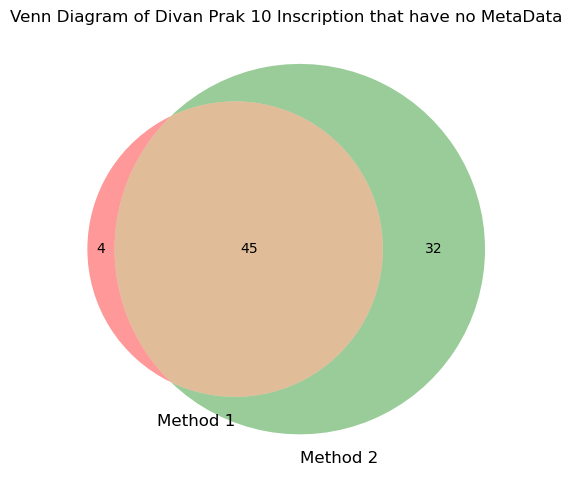

In [24]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

A=set(df_cleaned[df_cleaned['note'].isna()]['inscribtion_number'])
B=set(df_gen[df_gen['note']=="None"]['inscription_number'])

plt.figure(figsize=(6,6))
v = venn2([A, B], set_labels=("Method 1", "Method 2"))

plt.title("Venn Diagram of Divan Prak 10 Inscription that have no MetaData")
plt.show()